# Week 2: SVM and Naive Bayes on Adult Income

## Goal

Build reproducible binary classifiers that predict whether a person's income is `>50K` from the local `adult.csv` dataset. The notebook compares a majority-class baseline, Gaussian Naive Bayes, and an RBF Support Vector Machine (SVM).

The workflow treats `?` as missing data, splits the raw rows before fitting preprocessing, and evaluates every model on the same stratified test set.

## Setup

The notebook uses only the dataset stored beside it; no download or internet connection is required.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.30

## Steps

### 1. Load and inspect the local dataset

In [2]:
candidate_paths = [Path("adult.csv"), Path("Week 2") / "adult.csv"]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("adult.csv was not found beside the notebook or under Week 2/")

adult = pd.read_csv(DATA_PATH)
adult.columns = adult.columns.str.strip()

# Normalize whitespace and convert the Adult dataset's '?' token to missing values.
object_columns = adult.select_dtypes(include="object").columns
adult[object_columns] = adult[object_columns].apply(lambda column: column.str.strip())
adult[object_columns] = adult[object_columns].replace("?", np.nan)

print(f"Source: {DATA_PATH.resolve()}")
print(f"Rows: {adult.shape[0]:,} | Columns: {adult.shape[1]}")
display(adult.head())

Source: D:\Programming\SEM-5 ML labs\Week 2\adult.csv
Rows: 152 | Columns: 15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
target_counts = adult["income"].value_counts().rename_axis("income").to_frame("rows")
target_counts["percent"] = (100 * target_counts["rows"] / len(adult)).round(1)

missing_summary = adult.isna().sum()
missing_summary = missing_summary[missing_summary.gt(0)].sort_values(ascending=False).to_frame("missing_rows")

print("Target distribution")
display(target_counts)
print("Missing values after converting '?' to NaN")
display(missing_summary if not missing_summary.empty else pd.DataFrame({"missing_rows": []}))

Target distribution


,rows,percent
income,,
<=50K,79,52.0
>50K,73,48.0


Missing values after converting '?' to NaN


,missing_rows
workclass,2
occupation,2
native-country,2


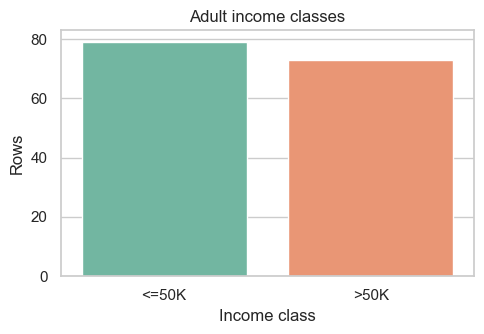

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=adult, x="income", hue="income", legend=False, palette="Set2", ax=ax)
ax.set(title="Adult income classes", xlabel="Income class", ylabel="Rows")
plt.tight_layout()
plt.show()

### 2. Define features and create a stratified split

`income` is converted to 1 for `>50K` and 0 for `<=50K`. All other columns are candidate predictors. The raw rows are split before any imputer, encoder, or scaler is fitted.

In [5]:
X = adult.drop(columns="income")
y = adult["income"].eq(">50K").astype(int).rename("income_gt_50k")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Positive-class rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Training rows: 106 | Test rows: 46
Numeric features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Positive-class rate — train: 0.481, test: 0.478


### 3. Build leakage-safe preprocessing and model pipelines

In [6]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )

models = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "Gaussian Naive Bayes": Pipeline(
        steps=[("preprocess", make_preprocessor()), ("model", GaussianNB())]
    ),
    "RBF SVM": Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)),
        ]
    ),
}

### 4. Train and compare the models

In [7]:
def positive_scores(model, features):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)


evaluation_rows = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)
    score = positive_scores(model, X_test)
    predictions[model_name] = predicted
    evaluation_rows.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predicted),
            "Precision": precision_score(y_test, predicted, zero_division=0),
            "Recall": recall_score(y_test, predicted, zero_division=0),
            "F1": f1_score(y_test, predicted, zero_division=0),
            "ROC AUC": roc_auc_score(y_test, score),
        }
    )

results = pd.DataFrame(evaluation_rows).set_index("Model").sort_values("F1", ascending=False)
display(results.style.format("{:.3f}"))

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
RBF SVM,0.935,0.880,1.000,0.936,0.992
Gaussian Naive Bayes,0.848,0.778,0.955,0.857,0.891
Majority baseline,0.522,0.000,0.000,0.000,0.500


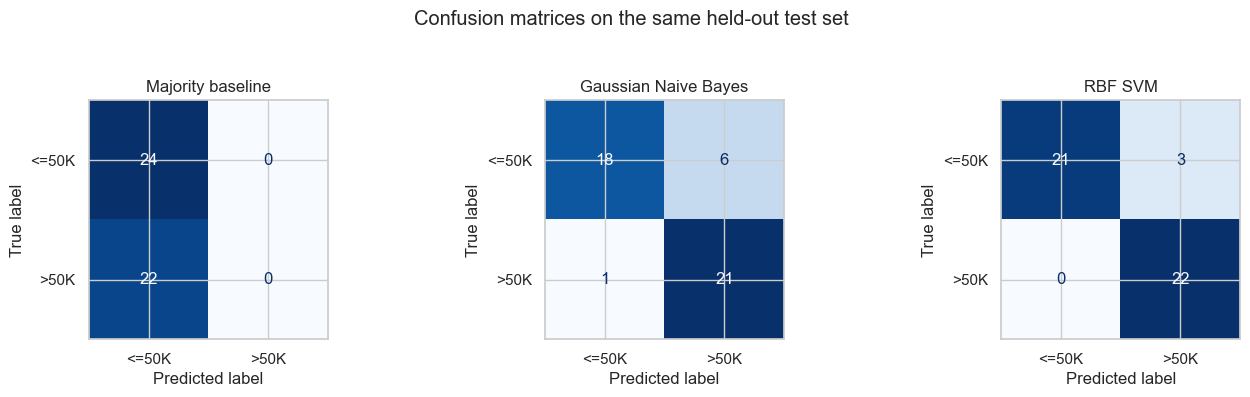

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(14, 3.8))
for axis, (model_name, predicted) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicted,
        display_labels=["<=50K", ">50K"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(model_name)
plt.suptitle("Confusion matrices on the same held-out test set", y=1.04)
plt.tight_layout()
plt.show()

### 5. Inspect per-class performance

In [9]:
for model_name in ["Gaussian Naive Bayes", "RBF SVM"]:
    print(f"\n{model_name}")
    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=["<=50K", ">50K"],
            zero_division=0,
        )
    )


Gaussian Naive Bayes
              precision    recall  f1-score   support

       <=50K       0.95      0.75      0.84        24
        >50K       0.78      0.95      0.86        22

    accuracy                           0.85        46
   macro avg       0.86      0.85      0.85        46
weighted avg       0.87      0.85      0.85        46


RBF SVM
              precision    recall  f1-score   support

       <=50K       1.00      0.88      0.93        24
        >50K       0.88      1.00      0.94        22

    accuracy                           0.93        46
   macro avg       0.94      0.94      0.93        46
weighted avg       0.94      0.93      0.93        46



## Checks

In [10]:
assert X_train.index.intersection(X_test.index).empty, "Train/test row overlap detected"
assert set(y.unique()) == {0, 1}, "Target encoding is not binary"

fitted_preprocessor = models["Gaussian Naive Bayes"].named_steps["preprocess"]
transformed_train = fitted_preprocessor.transform(X_train)
assert np.isfinite(transformed_train).all(), "Preprocessed data contains missing or infinite values"

print("Checks passed:")
print("- train and test row indices are disjoint")
print("- the target is binary")
print("- preprocessing produces only finite numeric values")

Checks passed:
- train and test row indices are disjoint
- the target is binary
- preprocessing produces only finite numeric values


## Takeaways and Next Steps

- On the executed 46-row test set, the RBF SVM achieved **93.5% accuracy** and **0.936 F1**, outperforming Gaussian Naive Bayes at **84.8% accuracy** and **0.857 F1**. Both models clearly exceeded the 52.2% majority-class baseline.
- This folder contains only 152 records, so a few test predictions can move the metrics substantially. Cross-validation on a larger Adult dataset would give a more stable estimate.
- Hyperparameter tuning should be performed only within the training data (for example, with cross-validation) so that the test set remains an unbiased final check.